In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, InputLayer, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

E0000 00:00:1736696293.879169      13 common_lib.cc:798] Could not set metric server port: INVALID_ARGUMENT: Could not find SliceBuilder port 8471 in any of the 0 ports provided in `tpu_process_addresses`="local"
=== Source Location Trace: === 
learning/45eac/tfrc/runtime/common_lib.cc:479
D0112 15:38:13.887520394      13 config.cc:196]                        gRPC EXPERIMENT call_status_override_on_cancellation   OFF (default:OFF)
D0112 15:38:13.887535504      13 config.cc:196]                        gRPC EXPERIMENT call_v3                                OFF (default:OFF)
D0112 15:38:13.887538928      13 config.cc:196]                        gRPC EXPERIMENT canary_client_privacy                  ON  (default:ON)
D0112 15:38:13.887541396      13 config.cc:196]                        gRPC EXPERIMENT capture_base_context                   ON  (default:ON)
D0112 15:38:13.887543766      13 config.cc:196]                        gRPC EXPERIMENT client_idleness                        ON  (defa

In [ ]:

df_2022 = pd.read_csv('/kaggle/input/arus-data/velocity_2022.csv')
df_2023 = pd.read_csv('/kaggle/input/arus-data/velocity_2023.csv')
df_2024 = pd.read_csv('/kaggle/input/arus-data/velocity_2024.csv')

df = pd.concat([df_2022, df_2023, df_2024], ignore_index=True)



In [ ]:
unique_coordinates = df[['Longitude', 'Latitude']].drop_duplicates().head(289)
unique_coords_list = list(zip(unique_coordinates['Longitude'], unique_coordinates['Latitude']))
filtered_df = df[df.apply(lambda row: (row['Longitude'], row['Latitude']) in unique_coords_list, axis=1)]
print(filtered_df.head())

                  Time   Longitude  Latitude    Velocity
0  2022-11-27 08:00:00  105.853733 -6.009025  112.900960
1  2022-11-27 08:00:00  105.817612 -5.873383  204.261870
2  2022-11-27 08:00:00  105.980159 -5.882413  130.130763
3  2022-11-27 08:00:00  105.971128 -5.882415  127.492955
4  2022-11-27 08:00:00  105.962098 -5.882416  136.243628


In [ ]:
filtered_df['time'] = pd.to_datetime(filtered_df['Time'], format='mixed', dayfirst=True)

filtered_df['year'] = filtered_df['time'].dt.year
filtered_df['month'] = filtered_df['time'].dt.month
filtered_df['day'] = filtered_df['time'].dt.day
filtered_df['hour'] = filtered_df['time'].dt.hour
filtered_df['minute'] = filtered_df['time'].dt.minute

/tmp/ipykernel_13/575141510.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['time'] = pd.to_datetime(filtered_df['Time'], format='mixed', dayfirst=True)
/tmp/ipykernel_13/575141510.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['year'] = filtered_df['time'].dt.year
/tmp/ipykernel_13/575141510.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documen

In [ ]:
print(filtered_df.tail())
print(filtered_df.info())

                         Time   Longitude  Latitude    Velocity       time  \
19197078  2024-07-10 00:00:00  105.935003 -5.855293  101.919390 2024-07-10   
19197079  2024-07-10 00:00:00  105.944033 -5.855291   93.298833 2024-07-10   
19197080  2024-07-10 00:00:00  105.953063 -5.855290  107.064183 2024-07-10   
19197081  2024-07-10 00:00:00  105.907914 -5.864339  109.319211 2024-07-10   
19197473  2024-07-10 00:00:00  105.962093 -5.855288  103.084259 2024-07-10   

          year  month  day  hour  minute  
19197078  2024      7   10     0       0  
19197079  2024      7   10     0       0  
19197080  2024      7   10     0       0  
19197081  2024      7   10     0       0  
19197473  2024      7   10     0       0  
<class 'pandas.core.frame.DataFrame'>
Index: 11779563 entries, 0 to 19197473
Data columns (total 10 columns):
 #   Column     Dtype         
---  ------     -----         
 0   Time       object        
 1   Longitude  float64       
 2   Latitude   float64       
 3   Vel

In [ ]:
print(df.isna().sum())
print((df == np.inf).sum())

Time         0
Longitude    0
Latitude     0
Velocity     0
dtype: int64
Time         0
Longitude    0
Latitude     0
Velocity     0
dtype: int64


In [ ]:
df.dropna(inplace=True)

In [ ]:
num_duplicates = filtered_df.duplicated().sum()
print(f"Jumlah data duplikat: {num_duplicates}")

Jumlah data duplikat: 181431


In [ ]:
filtered_df = filtered_df.drop_duplicates()

In [ ]:
features = filtered_df[['Longitude', 'Latitude','Velocity', 'year', 'month', 'day', 'hour']]
target = filtered_df[['Velocity']]

In [ ]:
# Scaling data
scaler_features = MinMaxScaler(feature_range=(0, 1))
scaled_features = scaler_features.fit_transform(features)
scaler_target = MinMaxScaler(feature_range=(0, 1))
scaled_target = scaler_target.fit_transform(target)

In [ ]:
SEQ_LENGTH = 60

def create_sequences(data, target, seq_length):
    xs, ys = [], []
    for i in range(len(data) - seq_length):
        x = data[i:i + seq_length]
        y = target[i + seq_length]
        xs.append(x)
        ys.append(y)
    return np.array(xs), np.array(ys)

X, y = create_sequences(scaled_features, scaled_target, SEQ_LENGTH)
X = X.reshape((X.shape[0], X.shape[1], X.shape[2]))

split = int(0.9 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

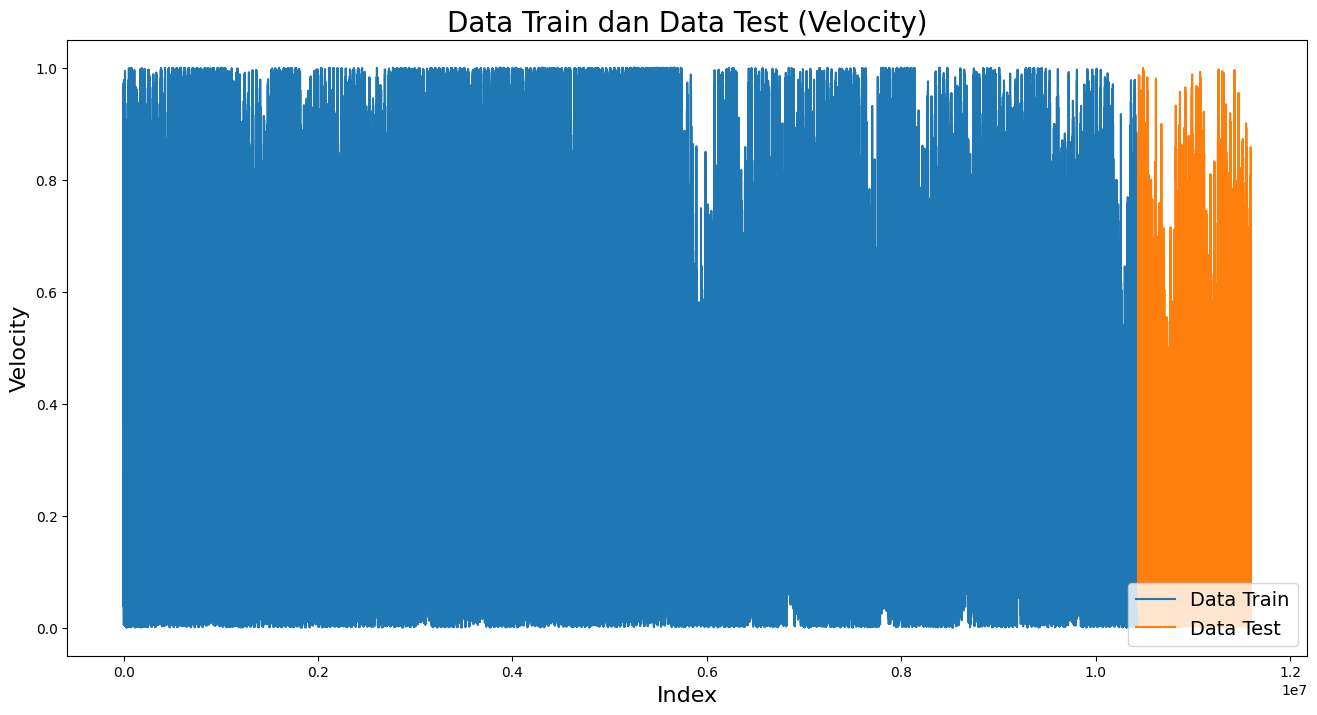

In [ ]:
import matplotlib.pyplot as plt

df_train = pd.DataFrame(y_train, columns=['Velocity'], index=range(len(y_train)))
df_test = pd.DataFrame(y_test, columns=['Velocity'], index=range(len(y_train), len(y_train) + len(y_test)))

plt.figure(figsize=(16, 8))
plt.title('Data Train dan Data Test (Velocity)', fontsize=20)
plt.ylabel('Velocity', fontsize=16)
plt.xlabel('Index', fontsize=16)
plt.plot(df_train, label='Data Train')
plt.plot(df_test, label='Data Test')
plt.legend(loc='lower right', fontsize=14)
plt.show()


In [ ]:
import tensorflow as tf

# Membuat TPU resolver untuk menghubungkan ke TPU
try:
    tpu = tf.distribute.cluster_resolver.TPUClusterResolver()  # Mendapatkan TPU
    print('TPU detected:', tpu)
except ValueError:
    tpu = None
    print('No TPU detected')

if tpu:
    # Memulai TPU
    tf.config.experimental_connect_to_cluster(tpu)
    tf.tpu.experimental.initialize_tpu_system(tpu)
    strategy = tf.distribute.TPUStrategy(tpu)  # Membuat strategi TPU
    print('TPU initialized')
else:
    strategy = tf.distribute.get_strategy()  # Gunakan strategi default (misal: CPU/GPU)

# Gunakan strategy.scope untuk membangun dan melatih model di dalam lingkungan TPU atau GPU/CPU


TPU detected: <tensorflow.python.distribute.cluster_resolver.tpu.tpu_cluster_resolver.TPUClusterResolver object at 0x7e4047972350>
INFO:tensorflow:Deallocate tpu buffers before initializing tpu system.
INFO:tensorflow:Initializing the TPU system: local


I0000 00:00:1736696871.585286      13 service.cc:145] XLA service 0x55eff2b98960 initialized for platform TPU (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1736696871.585361      13 service.cc:153]   StreamExecutor device (0): TPU, 2a886c8
I0000 00:00:1736696871.585366      13 service.cc:153]   StreamExecutor device (1): TPU, 2a886c8
I0000 00:00:1736696871.585370      13 service.cc:153]   StreamExecutor device (2): TPU, 2a886c8
I0000 00:00:1736696871.585373      13 service.cc:153]   StreamExecutor device (3): TPU, 2a886c8
I0000 00:00:1736696871.585375      13 service.cc:153]   StreamExecutor device (4): TPU, 2a886c8
I0000 00:00:1736696871.585379      13 service.cc:153]   StreamExecutor device (5): TPU, 2a886c8
I0000 00:00:1736696871.585382      13 service.cc:153]   StreamExecutor device (6): TPU, 2a886c8
I0000 00:00:1736696871.585384      13 service.cc:153]   StreamExecutor device (7): TPU, 2a886c8


INFO:tensorflow:Finished initializing TPU system.
INFO:tensorflow:Found TPU system:
INFO:tensorflow:*** Num TPU Cores: 8
INFO:tensorflow:*** Num TPU Workers: 1
INFO:tensorflow:*** Num TPU Cores Per Worker: 8
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:CPU:0, CPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:0, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:1, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:2, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:3, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:4, TPU, 0, 0)
INFO:tensorflow:*** Available Device: _DeviceAttributes(/job:localhost/replica:0/task:0/device:TPU:5, TPU, 0, 0)
I

In [ ]:
with strategy.scope():
    learning_rate = 0.0001
    optimizer = Adam(learning_rate=learning_rate, clipnorm=1.0)

    model = Sequential()
    model.add(LSTM(256, return_sequences=True, input_shape=(SEQ_LENGTH, X.shape[2])))
    model.add(Dropout(0.2))
    model.add(LSTM(256, return_sequences = True))
    model.add(Dropout(0.2))
    model.add(LSTM(128, return_sequences = True))
    model.add(Dropout(0.2))
    model.add(LSTM(128, return_sequences = True))
    model.add(Dropout(0.2))
    model.add(LSTM(128))
    model.add(Dropout(0.2))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    checkpoint_path = "/kaggle/working/model_arus.keras"
    try:
        model.load_weights(checkpoint_path)
        print("Model weights loaded from checkpoint.")
    except:
        print("No checkpoint found. Training from scratch.")

    checkpoint_callback = ModelCheckpoint(
        filepath=checkpoint_path,
        save_weights_only=False,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    )

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    )


    EPOCHS = 100
    BATCH_SIZE = 512 * strategy.num_replicas_in_sync

    history = model.fit(
         X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_data=(X_test, y_test),
        callbacks=[checkpoint_callback, early_stop]
    )

I0000 00:00:1736663753.026567      13 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
/usr/local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


No checkpoint found. Training from scratch.
Epoch 1/100


2025-01-12 06:36:47.153571: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node StatefulPartitionedCall.
I0000 00:00:1736663808.177058     828 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(7bae4681e3c1f94c:0:0), session_name()
I0000 00:00:1736663819.575011     828 tpu_compile_op_common.cc:245] Compilation of 7bae4681e3c1f94c:0:0 with session name  took 11.397899589s and succeeded
I0000 00:00:1736663819.622212     828 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(7bae4681e3c1f94c:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_4198410190190179027", property.function_library_fingerprint = 15000939392718669145, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z 

2548/2549 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0171

I0000 00:00:1736664156.402451     833 tpu_compilation_cache_interface.cc:441] TPU host compilation cache miss: cache_key(5a5a6250f8b0e071:0:0), session_name()


2549/2549 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0171

I0000 00:00:1736664167.434583     833 tpu_compile_op_common.cc:245] Compilation of 5a5a6250f8b0e071:0:0 with session name  took 11.032086578s and succeeded
I0000 00:00:1736664167.478079     833 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(5a5a6250f8b0e071:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_4198410190190179027", property.function_library_fingerprint = 15000939392718669145, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "207,60,7,;207,1,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1736664167.478119     833 tpu_compilation_cache_interface.cc:541] After adding entry for key 5


Epoch 1: val_loss improved from inf to 0.00609, saving model to /kaggle/working/model_arus.keras


I0000 00:00:1736664183.301500     832 tpu_compile_op_common.cc:245] Compilation of 7fe8d8f071b06643:0:0 with session name  took 837.455587ms and succeeded
I0000 00:00:1736664183.306314     832 tpu_compilation_cache_interface.cc:475] TPU host compilation cache: compilation complete for cache_key(7fe8d8f071b06643:0:0), session_name(), subgraph_key(std::string(property.function_name) = "cluster_one_step_on_iterator_11977441952513487602", property.function_library_fingerprint = 13211481740042968834, property.mlir_module_fingerprint = 0, property.num_replicas = 8, topology.chip_bounds().x = 2, topology.chip_bounds().y = 2, topology.chip_bounds().z = 1, topology.wrap().x = false, topology.wrap().y = false, topology.wrap().z = false, std::string(property.shapes_prefix) = "80,60,7,;80,1,;", property.guaranteed_constants_size = 0, embedding_partitions_fingerprint = "1688352644216761960")
I0000 00:00:1736664183.306344     832 tpu_compilation_cache_interface.cc:541] After adding entry for key 7fe

2549/2549 ━━━━━━━━━━━━━━━━━━━━ 380s 143ms/step - loss: 0.0171 - val_loss: 0.0061
Epoch 2/100
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0101
Epoch 2: val_loss improved from 0.00609 to 0.00533, saving model to /kaggle/working/model_arus.keras
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 346s 135ms/step - loss: 0.0101 - val_loss: 0.0053
Epoch 3/100
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0095
Epoch 3: val_loss improved from 0.00533 to 0.00528, saving model to /kaggle/working/model_arus.keras
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 345s 135ms/step - loss: 0.0095 - val_loss: 0.0053
Epoch 4/100
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0093
Epoch 4: val_loss improved from 0.00528 to 0.00520, saving model to /kaggle/working/model_arus.keras
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 345s 135ms/step - loss: 0.0093 - val_loss: 0.0052
Epoch 5/100
2549/2549 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step - loss: 0.0091
Epoch 5: val_loss improved from 0.00520 to 0.00514, saving model to /kaggle/working/m

36244/36244 ━━━━━━━━━━━━━━━━━━━━ 4348s 120ms/step
Mean Squared Error (MSE): 186.71485474700984
Mean Absolute Error (MAE): 9.061376988054151
R² Score: 0.8685778837569949


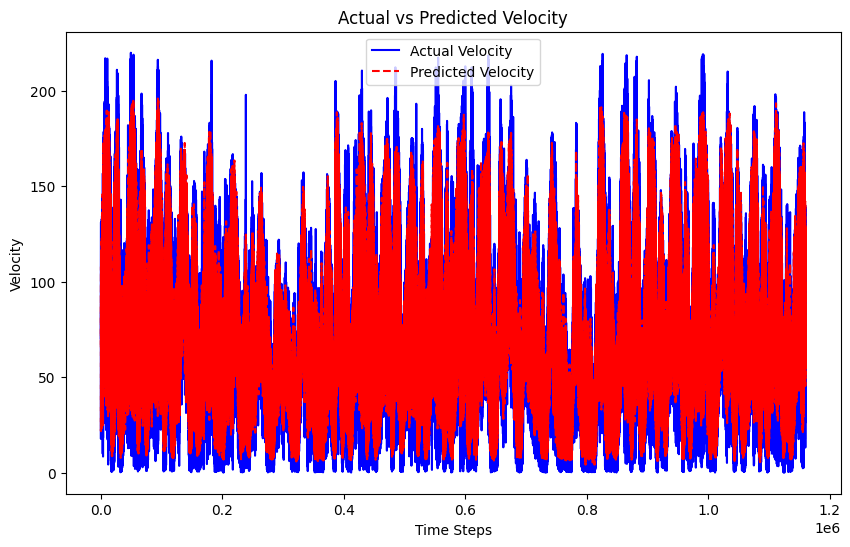

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import load_model

model = load_model("/kaggle/input/arus_pred/keras/default/1/model_arus (2).keras")
predictions = model.predict(X_test)

predicted = scaler_target.inverse_transform(predictions)[:, 0]
actual = scaler_target.inverse_transform(y_test)[:, 0]

mse = mean_squared_error(actual, predicted)
mae = mean_absolute_error(actual, predicted)
r2 = r2_score(actual, predicted)

print(f'Mean Squared Error (MSE): {mse}')
print(f'Mean Absolute Error (MAE): {mae}')
print(f'R² Score: {r2}')

plt.figure(figsize=(10, 6))
plt.plot(actual, label='Actual Velocity', color='blue')
plt.plot(predicted, label='Predicted Velocity', color='red', linestyle='dashed')
plt.title('Actual vs Predicted Velocity')
plt.xlabel('Time Steps')
plt.ylabel('Velocity')
plt.legend()
plt.show()


In [ ]:
df_hasil = pd.DataFrame({
    'Real Velocity': actual,
    'Predicted Velocity': predicted
})

print(df_hasil.tail(10))

         Real Velocity  Predicted Velocity
1159798      89.336849           87.570992
1159799      91.079204           96.613701
1159800     103.589755           99.457565
1159801     106.107405          106.956833
1159802     105.589192          105.183548
1159803     101.919390          102.207436
1159804      93.298833          100.424080
1159805     107.064183           96.387306
1159806     109.319211          102.767639
1159807     103.084259          101.086899
